# EDA — Predicting Daily Citi Bike Ridership
**TLAB IV, Part 2 — Notebook 1 of 3**

Goal of this notebook: explore `data/citibike_weather_daily.csv` (built in Part 1), document its
structure, distributions, and relationships with the target (`num_rides`), and **find the data
quality problems** before they find the model. Nothing gets fixed here — fixes happen in
`preprocessing.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/citibike_weather_daily.csv')

## E1: Load and Inspect

The data dictionary says the columns should be: `ride_date` (date), `num_rides` (integer),
`avg_duration_min` (float), four weather floats, `day_of_week` (string), `month` (integer).
Let's verify what pandas *actually* loaded.

In [2]:
print('Shape:', df.shape)
df.head()

Shape: (1610, 10)


,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.309988,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.968826,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.238808,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.218474,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.040443,84.4,93.0,75.9,9.0,0.00,Friday,7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_date         1610 non-null   str    
 1   num_rides         1610 non-null   int64  
 2   avg_duration_min  1610 non-null   float64
 3   temp_f            1610 non-null   float64
 4   max_temp_f        1610 non-null   float64
 5   min_temp_f        1610 non-null   float64
 6   wind_speed_knots  1610 non-null   float64
 7   precip_in         1610 non-null   float64
 8   day_of_week       1610 non-null   str    
 9   month             1610 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 125.9 KB


### E1 findings

| Column | Should be | Actually loaded as | OK? |
|---|---|---|---|
| `ride_date` | date | **object (string)** | ❌ |
| `num_rides` | integer | int64 | ✅ |
| `avg_duration_min` | float | float64 | ✅ |
| `temp_f`, `max_temp_f`, `min_temp_f` | float | float64 | ✅ |
| `wind_speed_knots`, `precip_in` | float | float64 | ✅ |
| `day_of_week` | string | object | ✅ |
| `month` | integer | int64 | ✅ |

**Problem found:** `ride_date` loaded as a plain string, not a datetime. My hypothesis: CSV files
have no type information — every cell is just text — and `pd.read_csv` only auto-converts columns
that look numeric. Date strings like `2013-07-01` stay as strings unless we explicitly ask for
`parse_dates` or convert afterwards. Until it's fixed we can't do date arithmetic, resampling, or
extract components like year. **Fix goes in preprocessing (C1), not here.**

## E2: Profile the Distributions

`.describe()` plus a histogram of every numeric column. For each one: are the min and max
physically possible? NOAA's GSOD documentation warns that missing observations are *coded as
numbers*: `9999.9` (temperatures), `999.9` (wind), `99.99` (precipitation). Let's hunt for those.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_rides,1610.0,32986.783230,16910.147968,876.000000,20505.500000,32272.500000,42915.750000,78458.000000
avg_duration_min,1610.0,15.425627,3.652633,9.495396,13.112342,14.860057,17.121551,81.110084
temp_f,1610.0,57.368509,17.876211,8.300000,43.625000,59.300000,73.500000,92.500000
max_temp_f,1610.0,67.317081,18.349408,18.000000,53.700000,70.000000,82.900000,100.900000
min_temp_f,1610.0,49.295901,17.832318,1.000000,35.700000,51.100000,64.900000,82.900000
wind_speed_knots,1610.0,9.013913,3.241211,2.300000,6.700000,8.500000,10.800000,22.400000
precip_in,1610.0,0.178398,2.508762,0.000000,0.000000,0.000000,0.060000,99.990000
month,1610.0,6.544099,3.323772,1.000000,4.000000,7.000000,9.000000,12.000000


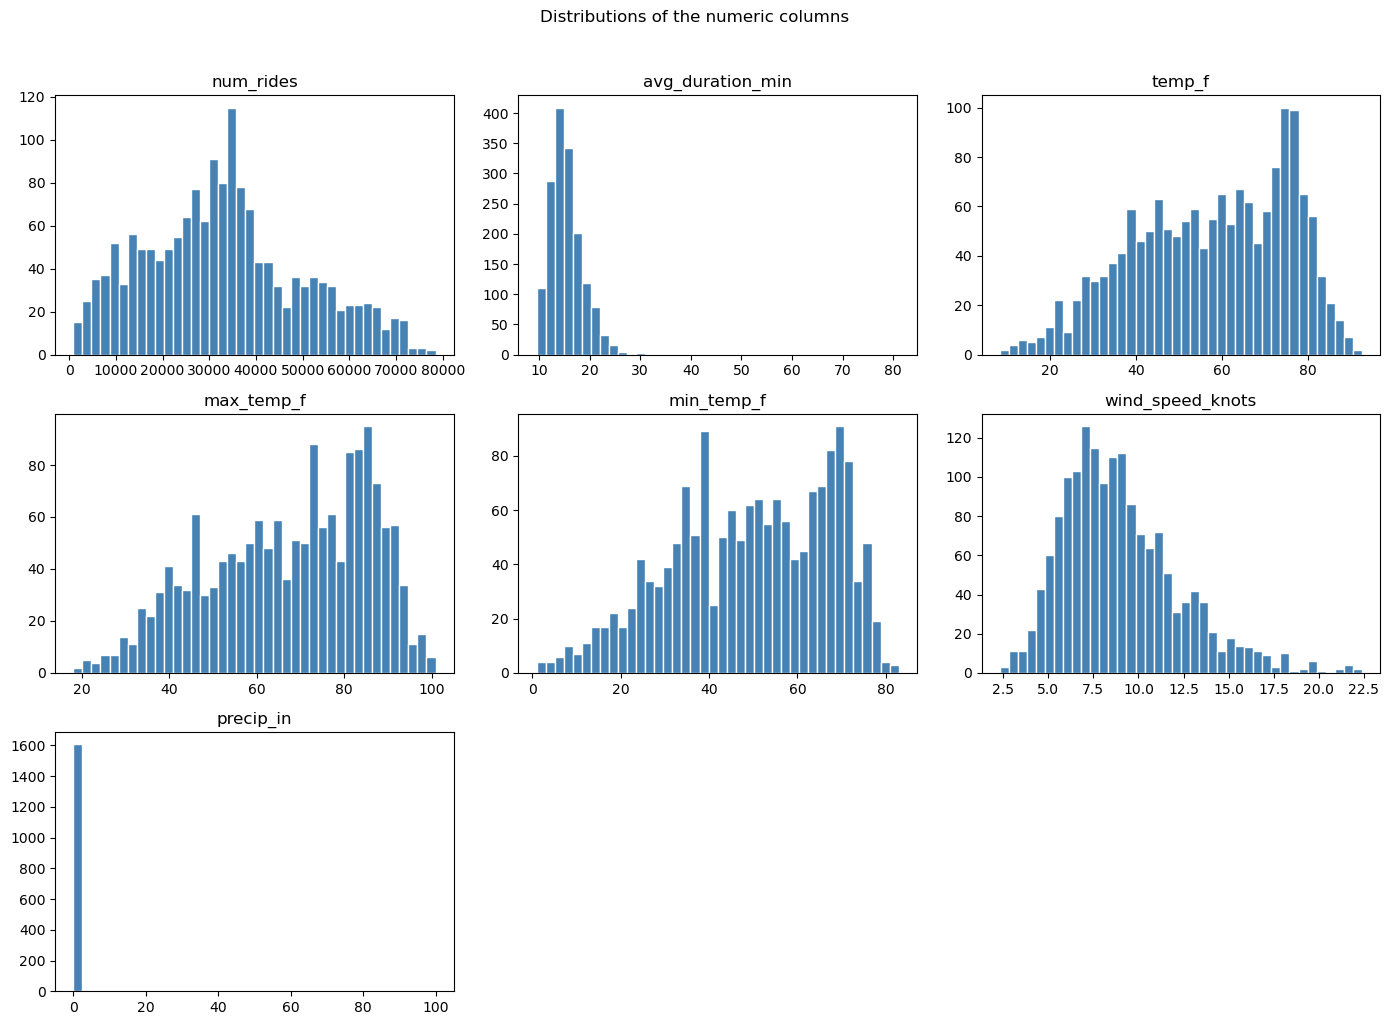

In [5]:
numeric_cols = ['num_rides', 'avg_duration_min', 'temp_f', 'max_temp_f',
                'min_temp_f', 'wind_speed_knots', 'precip_in']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis('off')
fig.suptitle('Distributions of the numeric columns', y=1.02)
fig.tight_layout()
plt.show()

In [6]:
# Sentinel hunt: did any NOAA missing-value codes make it into our slice?
sentinels = {'temp_f': 9999.9, 'max_temp_f': 9999.9, 'min_temp_f': 9999.9,
             'wind_speed_knots': 999.9, 'precip_in': 99.99}

for col, code_val in sentinels.items():
    n = (df[col] == code_val).sum()
    print(f'{col:18s} sentinel {code_val:>7}: {n} row(s)')

temp_f             sentinel  9999.9: 0 row(s)
max_temp_f         sentinel  9999.9: 0 row(s)
min_temp_f         sentinel  9999.9: 0 row(s)
wind_speed_knots   sentinel   999.9: 0 row(s)
precip_in          sentinel   99.99: 1 row(s)


In [7]:
# There it is — look at the affected row and its neighbors
hit = df[df['precip_in'] == 99.99]
print('Sentinel row(s):')
display(hit)

idx = hit.index[0]
print('\nNeighboring days:')
df.loc[idx - 3: idx + 3, ['ride_date', 'temp_f', 'precip_in']]

Sentinel row(s):


,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
951,2016-02-11,18748,13.523118,28.1,39.9,23.0,17.3,99.99,Thursday,2



Neighboring days:


,ride_date,temp_f,precip_in
948,2016-02-08,36.7,0.00
949,2016-02-09,30.2,0.06
950,2016-02-10,35.4,0.01
951,2016-02-11,28.1,99.99
952,2016-02-12,21.7,0.05
953,2016-02-13,21.6,0.00
954,2016-02-14,8.3,0.00


### E2 findings

- **`precip_in` has a max of 99.99 inches** — that is not rain, that's NOAA's missing-value code
  for precipitation. Exactly **one row** is affected: **2016-02-11**. Its neighbors that week
  recorded 0.00–0.06 in, so the true value was almost certainly near zero. (The `.describe()`
  mean of 0.18 in and std of 2.5 in are both inflated by this single sentinel.)
- No temperature (`9999.9`) or wind (`999.9`) sentinels made it into our slice.
- Everything else is physically plausible: temps from 8.3 °F to 100.9 °F is a believable NYC
  range, wind 2.3–22.4 knots is fine, and `num_rides` from 876 to 78,458 is wide but real —
  the low end will turn out to be blizzard-adjacent days.
- `avg_duration_min` has a long right tail (max ≈ 81 min vs median ≈ 15). Worth noting, but this
  column is barred from the model anyway (Rule 1: it's derived from that day's rides).

**Fix for the sentinel goes in preprocessing (C2).**

## E3: Relationships With the Target

Scatter plots of `num_rides` against each weather variable. Which relationships will the model
be able to lean on?

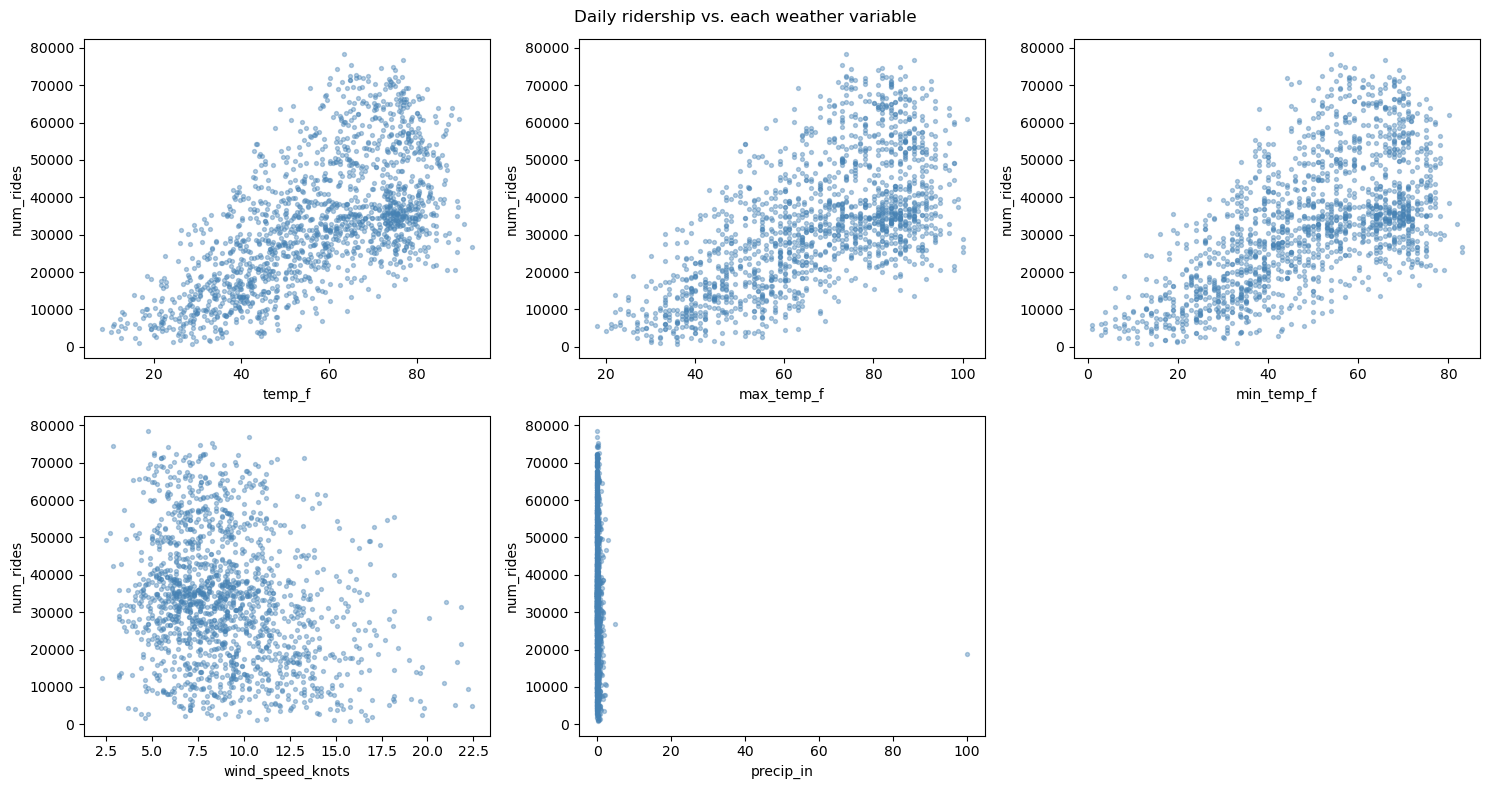

In [8]:
weather_cols = ['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots', 'precip_in']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, weather_cols):
    ax.scatter(df[col], df['num_rides'], s=8, alpha=0.4, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('num_rides')
axes.flat[-1].axis('off')
fig.suptitle('Daily ridership vs. each weather variable')
fig.tight_layout()
plt.show()

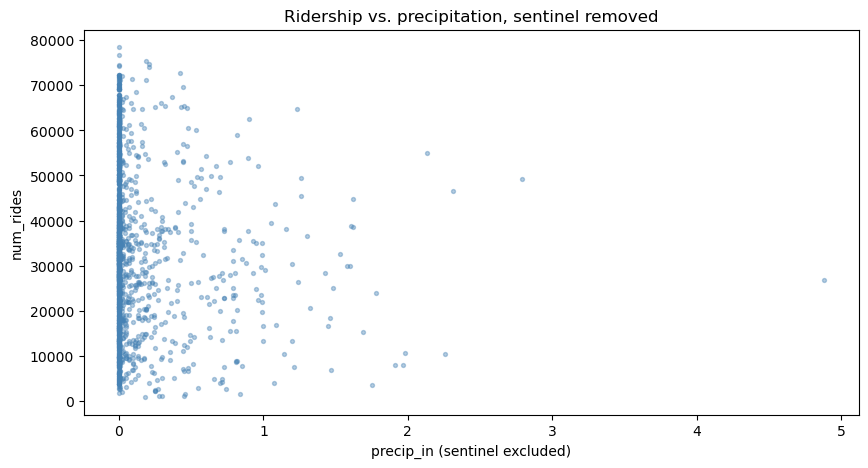

In [9]:
# Precipitation is unreadable with the 99.99 sentinel on the x-axis — replot without it
no_sentinel = df[df['precip_in'] < 99]
plt.scatter(no_sentinel['precip_in'], no_sentinel['num_rides'], s=8, alpha=0.4, color='steelblue')
plt.xlabel('precip_in (sentinel excluded)')
plt.ylabel('num_rides')
plt.title('Ridership vs. precipitation, sentinel removed')
plt.show()

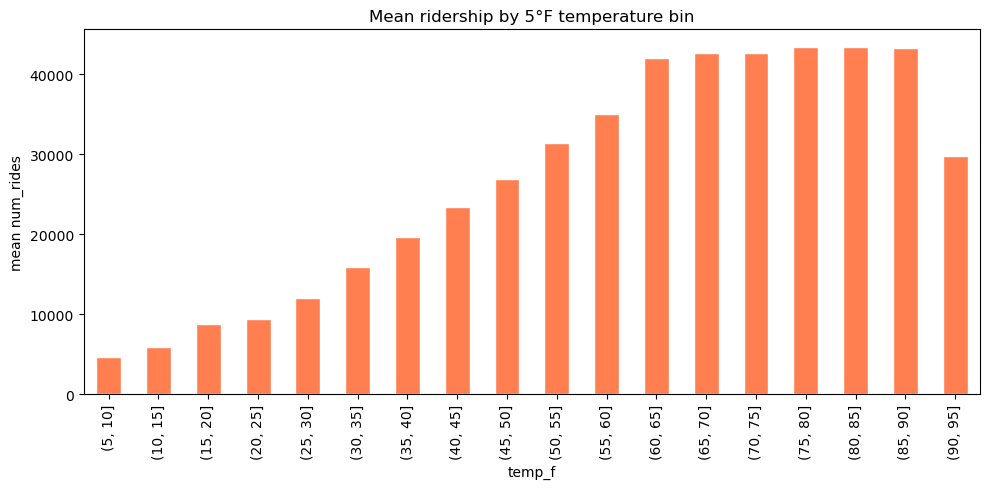

Mean rides, 70–85°F: 43122
Mean rides,  > 85°F: 42378


In [10]:
# Zoom in on the hottest days: does ridership keep climbing forever?
bins = pd.cut(df['temp_f'], bins=range(0, 101, 5))
by_temp = df.groupby(bins, observed=True)['num_rides'].mean()
by_temp.plot(kind='bar', color='coral', edgecolor='white')
plt.ylabel('mean num_rides')
plt.title('Mean ridership by 5°F temperature bin')
plt.tight_layout()
plt.show()

print('Mean rides, 70–85°F:', int(df[(df.temp_f > 70) & (df.temp_f <= 85)]['num_rides'].mean()))
print('Mean rides,  > 85°F:', int(df[df.temp_f > 85]['num_rides'].mean()))

### E3 findings

- **Temperature is by far the strongest relationship** — a clear positive trend. All three
  temperature columns (`temp_f`, `max_temp_f`, `min_temp_f`) show essentially the *same* scatter
  shape, which previews Rule 2: they move together and are not three independent signals.
- **The temperature relationship is curved, not straight.** Ridership climbs steeply from
  freezing up to the mid-70s, then **flattens and even dips past ~85 °F** (mean rides at >85 °F
  is slightly *below* the 70–85 °F mean). People don't ride more in a heat wave. A straight line
  can't capture "rises then plateaus" — remember this for feature engineering (a squared
  temperature term is the classic fix).
- **Precipitation is negative but weak-looking** in raw scatter form: most days have zero rain,
  and rainy days sit visibly lower. The relationship is real but concentrated in a minority of days.
- **Wind is weakly negative** — high-wind days lean lower, but with lots of spread.
- Vertical banding in every plot hints there's a second dimension (day of week / year) that
  weather alone doesn't explain.

## E4: Ridership Over Time

Plot the full date range, then compare the same month across years.

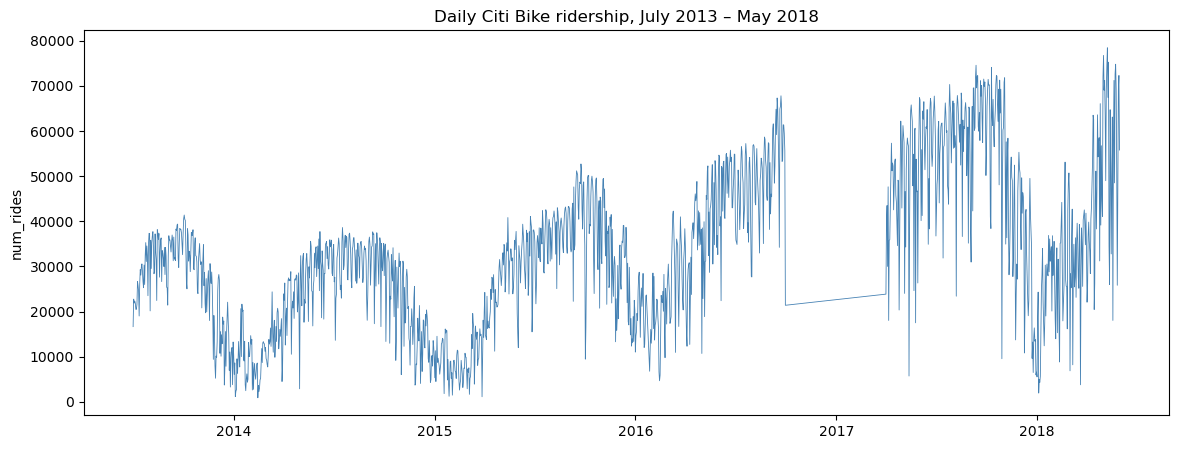

In [11]:
# ride_date is still a string (E1) — convert to a temporary datetime just for plotting.
# The permanent fix belongs in preprocessing.
dates = pd.to_datetime(df['ride_date'])

plt.figure(figsize=(14, 5))
plt.plot(dates, df['num_rides'], lw=0.6, color='steelblue')
plt.ylabel('num_rides')
plt.title('Daily Citi Bike ridership, July 2013 – May 2018')
plt.show()

ride_date
2013    27207.0
2014    31253.0
2015    35022.0
2016    44520.0
2017    55987.0
Name: num_rides, dtype: float64


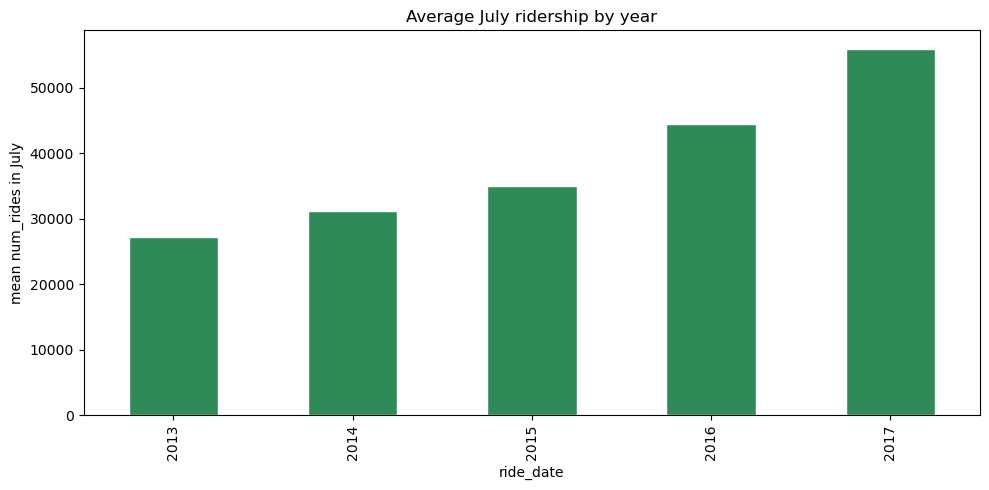

In [12]:
# Same month, different years: average July ridership
july = df[df['month'] == 7].copy()
july_means = july.groupby(dates[july.index].dt.year)['num_rides'].mean().round(0)
print(july_means)

july_means.plot(kind='bar', color='seagreen', edgecolor='white')
plt.ylabel('mean num_rides in July')
plt.title('Average July ridership by year')
plt.tight_layout()
plt.show()

### E4 findings

A July day in 2017 is **not** the same as a July day in 2013 — not even close. Average July
ridership roughly **doubled** over the period: ~27,200 rides/day in July 2013 vs ~35,000 in
July 2015 vs ~56,000 in July 2017. Identical weather, wildly different ridership.

Why: the *system itself* grew — more stations, more bikes, more members every year. That growth
is visible in the time-series plot as an upward drift underneath the seasonal wave.

**Implication for the model:** a model whose only inputs are weather and day-of-week is blind to
what year it is. It would systematically over-predict 2013 and under-predict 2017 by thousands
of rides. The model needs a **trend feature** (year, or days since launch) — that's
preprocessing task C4. There's also a visible gap in the line around late 2016 / early 2017,
which E6 will quantify.

## E5: The Weekly Rhythm

Compare ridership across days of the week.

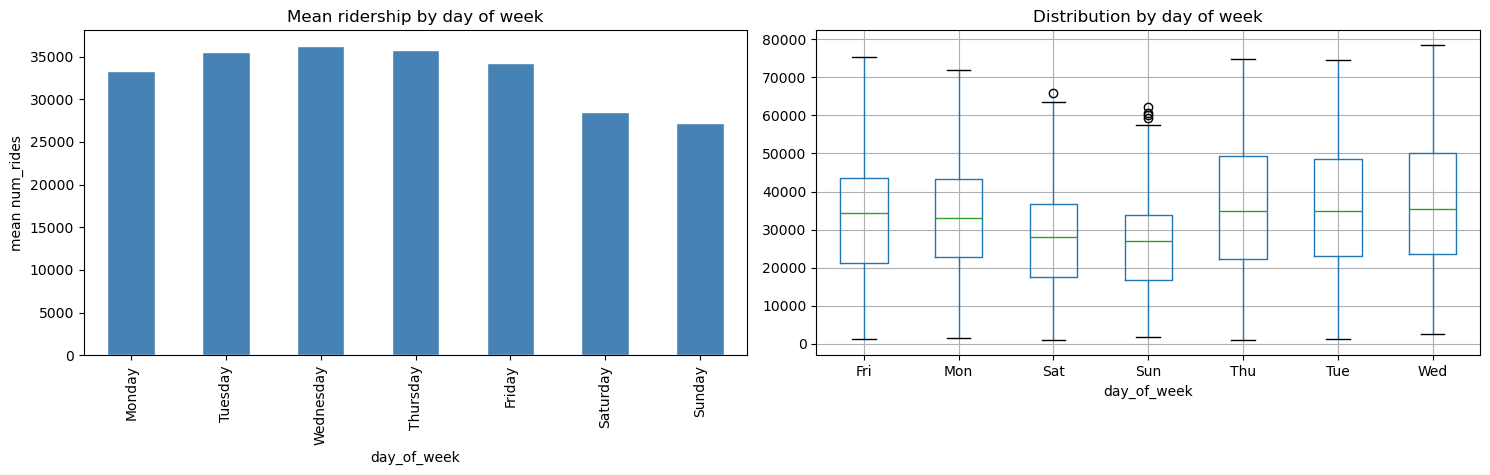

In [13]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df.groupby('day_of_week')['num_rides'].mean().reindex(dow_order).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mean ridership by day of week')
axes[0].set_ylabel('mean num_rides')

df.boxplot(column='num_rides', by='day_of_week', ax=axes[1])
axes[1].set_xticklabels([t.get_text()[:3] for t in axes[1].get_xticklabels()])
axes[1].set_title('Distribution by day of week')
plt.suptitle('')
fig.tight_layout()
plt.show()

### E5 findings

**Weekdays beat weekends.** Wednesday (~36,300) and Thursday (~35,700) are the busiest;
Sunday (~27,300) and Saturday (~28,600) are the quietest — roughly a 20–25% weekend drop.

That matches intuition about who rides Citi Bike and why: it's heavily a **commuter system**.
The Monday–Friday peak is people riding to work; weekends fall back to leisure traffic. Day of
week clearly carries signal the model needs — but `'Tuesday'` can't be multiplied by a
coefficient, so preprocessing (C3) will one-hot encode it.

## E6: The Missing Days

The table has 1,610 rows, but the date span contains more days than that. How many are missing,
and *where* do the gaps fall?

In [14]:
all_days = pd.date_range(dates.min(), dates.max())
have = pd.DatetimeIndex(dates)
missing = all_days.difference(have)

print(f'Date span: {dates.min().date()} → {dates.max().date()} = {len(all_days)} days')
print(f'Rows we have: {len(df)}')
print(f'Missing dates: {len(missing)}')

Date span: 2013-07-01 → 2018-05-31 = 1796 days
Rows we have: 1610
Missing dates: 186


In [15]:
# Where do the gaps fall?
missing_by_month = pd.Series(missing).dt.to_period('M').value_counts().sort_index()
print(missing_by_month)

print('\nThe four isolated missing days:')
print([str(d.date()) for d in missing if d < pd.Timestamp('2016-06-01')])

2016-01     4
2016-10    31
2016-11    30
2016-12    31
2017-01    31
2017-02    28
2017-03    31
Freq: M, Name: count, dtype: int64

The four isolated missing days:
['2016-01-23', '2016-01-24', '2016-01-25', '2016-01-26']


### E6 findings

**186 dates are missing**, and they fall in two very different kinds of gap:

1. **Jan 23–26, 2016 (4 days).** That is exactly the weekend of **Winter Storm Jonas**, the
   record ~27-inch blizzard. NYC banned road travel and Citi Bike suspended service — so there
   were **no ride rows** those days. This gap came from the **rides side** of the Part 1 join.
2. **Oct 2016 – Mar 2017 (182 days — six complete months).** Every single day is missing, which
   no weather event explains. A clean, calendar-aligned block like this looks like the
   **weather station's data is absent** from GSOD for that stretch (or was dropped in our
   Part 1 slice) — this gap came from the **weather side** of the join.

Because Part 1 used an **INNER JOIN**, a day missing from *either* side vanishes from the CSV
entirely. That's why the table quietly has 186 fewer rows than the calendar — nothing ever
errored, the rows just aren't there.

## EDA Summary — the problem list handed to preprocessing

| # | Problem | Where found | Fix (notebook 2) |
|---|---|---|---|
| 1 | `ride_date` is a string, not datetime | E1 | C1: `pd.to_datetime` |
| 2 | `precip_in` = 99.99 sentinel on 2016-02-11 | E2 | C2: replace → NaN → impute |
| 3 | `day_of_week` is text, model needs numbers | E5 | C3: one-hot encode |
| 4 | System growth: July mean doubled 2013→2017 | E4 | C4: trend feature |
| 5 | Temperature effect is curved (plateaus >85 °F) | E3 | C5: squared temp term |
| 6 | 186 missing days (blizzard + 6-month station gap) | E6 | documented; rows can't be recovered |
| 7 | `temp_f`/`max_temp_f`/`min_temp_f` nearly collinear | E3 | Rule 2: use only one |
| 8 | `avg_duration_min` derived from same-day rides | — | Rule 1: excluded from features |